# T037 · 不确定性估计

**注：** 本教程是 TeachOpenCADD 的一部分。TeachOpenCADD 是一个旨在教授领域专用技能，并提供可作为研究项目起点的流程模板的平台。

作者：

- Michael Backenköhler, 2022, [Volkamer 实验室](https://volkamerlab.org), [NextAID](https://nextaid.cs.uni-saarland.de/) 项目, 萨尔大学


*本教程中使用的预测设置（和模型类）改编自 **教程 T022**。*


## 本教程的目标

研究人员通常只关注预测质量。然而，在应用预测模型时，研究人员也对他们在特定预测中的确定程度感兴趣。估计和提供此类信息是不确定性估计的目标。在本教程中，我们讨论一些常用的方法论，并在实践中展示集成方法。


### _理论_ 部分内容

* 为什么模型不能也不应该确定
* 校准
* 方法论概览
    * 单一确定性方法
    * 集成方法
    * 测试时数据增强


### _实践_ 部分内容

* 数据
* 模型
    * 训练
    * 评估
* 集成——多次训练模型
    * 置信区间的覆盖
    * 校准
    * 基于排序的评估
* Bagging 集成——使用不同数据训练模型
    * 基于排序的评估
* 测试时数据增强


### 参考文献

* [Gawlikowski, Jakob, et al. "A survey of uncertainty in deep neural networks." _arXiv preprint_ (2021), arXiv:2107.03342](https://arxiv.org/abs/2107.03342)
* [Sagi, O. and Rokach, L. "Ensemble learning: A survey". Wiley Interdisciplinary Reviews: Data Mining and Knowledge Discovery, 8(4), (2018) p.e1249.](https://wires.onlinelibrary.wiley.com/doi/abs/10.1002/widm.1249)
* [Scalia, Gabriele, et al. "Evaluating scalable uncertainty estimation methods for deep learning-based molecular property prediction." _Journal of chemical information and Modeling_ 60.6 (2020): 2697-2717](https://pubs.acs.org/doi/pdf/10.1021/acs.jcim.9b00975)
* __教程 T022__


In [1]:
import sys

if "google.colab" in sys.modules:
    %pip install teachopencadd --no-deps -q
    !teachopencadd -d 37
    %pip uninstall teachopencadd -y -q
    %pip install -qr requirements.txt

## 理论

研究人员经常非常关注整体估计的质量。
但要在实践中应用任何预测方法，知道对估计结果的_信任_程度同样重要。
因此，最好不仅有某物的点估计，而且还有关于给定估计结果我们有多_确定_的一些指示。
确定性通常通过用分布估计代替点估计来建模。
例如，输入上的模型 $f$ 不仅预测 $f(x)=\hat\theta$，而是预测一个[正态分布](https://en.wikipedia.org/wiki/Normal_distribution) $f(x)=N(\hat\theta, \hat\sigma)$。

### 为什么模型不能也不应该确定
在讨论如何估计不确定性之前，我们先看看不确定性的成因。
关于数据，我们可以区分两类不确定性。

1. _偶然不确定性_或_数据不确定性_是数据及其来源固有的
2. _认知不确定性_由模型的局限性引起

偶然不确定性是不可避免的，因为它内在于真实系统和我们收集数据的方式。
这是一种即使可以选择无限大的数据集也仍然存在的不确定性。
想象一下，你正在执行一个化学实验来确定某个化合物和蛋白质之间的结合亲和力。
即使你是一个非常细心的化学家，你很可能也无法每次都精确地重现相同的 $K_d$。
这种不确定性将始终存在于数据中。即使你将实验重复到老。

认知不确定性是可减少的不确定性。这是我们可以通过收集更多数据或改进模型来消除的不确定性。这通常也被称为模型不确定性。没有机器学习模型是完美的。
我们总是引入某种程度的简化和抽象。这给我们的预测带来了不确定性，即使在给定完美数据的情况下，这种不确定性仍然存在。让我们再次考虑上面提到的结合亲和力预测。如果我们只考虑使用相同骨架构建的分子，模型无法在这个领域之外学习。因此，对于基于其他骨架的分子，它很可能非常不确定。然而，给定其他骨架的数据，模型可以学习，因此不确定性会减少。

不确定性的另一个方面是训练和测试数据的领域。存在_域内_不确定性，即测试样本的不确定性应该"大致"被训练样本覆盖。_域外_和_域漂移_不确定性源于训练数据不能很好代表的测试数据。对于大多数领域来说，确定给定样本是域内还是域外是一个难题，因为需要很好地理解问题才能确定样本是否在训练域内。这个问题在化学信息学中尤其困难，因为相似性度量可能由于_活性悬崖_而失效。在活性悬崖处，分子在指纹等度量上可能非常相似，但目标性质却截然不同。

### 校准

假设我们有一个包含不确定性的机器学习模型。我们如何评估和改进预测的不确定性？
这就是校准的用武之地。
校准处理的是不确定性估计给出的置信度的准确性。例如，一个良好校准的估计应该得到 30% 的置信区间，该区间在极限情况下应以 0.3 的概率覆盖真实值。通常，神经网络模型倾向于过度自信。

有许多方法可以处理估计器的_校准_。其中最直接的方法之一是在训练后调整预测的不确定性。为此，我们可以使用一个留出的_校准集_。这个集目的是_调整_预测的不确定性。例如，在过度自信的模型中，它应该导致预测不确定性的增加。
在实践部分，我们演示了使用校准集进行简单的缩放。

### 方法论概览

有各种各样的方法可以提供不确定性估计。[Gawlikowski et al.](https://arxiv.org/abs/2107.03342) 给出了一个出色的综述。
在这里，我们坚持最常用和最广泛适用的方法。
这些方法——在模型方面——大致可以分为：
1. 单一确定性方法和
2. 集成方法。

一种与模型无关的方法是测试时数据增强。

#### 单一确定性方法

可以说是最直接的与点预测器一起预测不确定性的方法。通常这相当于预测一个分布而不是点估计。考虑在回归设置中预测正态分布的均值和方差参数作为示例。在分类设置中，我们通常预测类概率，这已经是一种不确定性预测，尽管有一些限制（参见 [Gawlikowski et al.](https://arxiv.org/abs/2107.03342)）。

另一种方法是直接预测不确定性。在这种情况下，训练一个次级模型来预测已经训练好的模型的不确定性。这有明显的优势，即不需要对预测模型本身进行任何修改。

#### 集成方法

集成方法建立在创建一个选择（即集成）的基础上，该选择由相似但不同的模型组成。作为这种集成的一个简单示例，考虑一个使用不同随机种子多次训练的神经网络模型。由于随机梯度下降中的固有随机性，每个训练版本的模型都会与其他版本不同。

![模型集成](images/nn.png)

*图 1：*
由多次不同训练运行获得的具有不同权重的相似模型的集成。

模型参数中的这种差异导致所有集成成员之间预测值的多样性。这种方差可以用作不确定性估计。正如我们将在下面的实践部分看到的，这种集成中的多样性通常可能不足。通常，此类集成中的多样性太小，因此不确定性被低估。

可以通过改变每次训练运行的训练数据来向集成引入额外的多样性。下面展示的一种简单方法是_bagging_，它是_bootstrap and aggregation_的缩写。在那里，对于每次训练运行，使用替换对训练数据进行重新采样，从而在得到的集成中增加多样性。

我们也可以修改测试数据以进行不确定性估计。在这方面，可以通过包含输入数据的略微修改版本来增强测试数据。但请注意，必须注意此类修改的确切方法。尤其是在化学领域，即使是看似微小的变化，如添加或移除一个键，也可能产生重大后果。这意味着，在模型的输入域和输出域之间的接近概念可能存在一些无意的分歧。

另一种增加集成多样性的方法是改变模型本身。这是通过显式改变模型的架构或通过具有概率性 dropout 的贝叶斯网络来完成的。在后一种情况下，由于随机的 dropout，我们在测试时实质上有了一个模型集成。

#### 测试时数据增强

另一种不确定性估计的方法是使用测试时数据增强。对于每个查询点，我们使用一些随机噪声创建一个增强的点集。在本 notebook 的实践示例中，我们处理的是指纹数据。
在这种二值数据中引入噪声的一种自然方式是以很小的概率翻转位。这样，我们为每个实际的查询点获得一组数据点。这反过来又为我们提供了对应于每个查询点的一组预测，希望这能代表该查询点的预测不确定性。


## 实践


简要总结实践部分将进行的操作。


In [2]:
from pathlib import Path
from warnings import filterwarnings

# 静默一些预期警告
filterwarnings("ignore")

import pandas as pd
from scipy.stats import norm
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("notebook")
import tqdm
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from IPython.display import display, Markdown

# reproducibility
torch.manual_seed(0)

%matplotlib inline

In [3]:
HERE = Path(".").absolute()
DATA = HERE / "data"

我们复用 **教程 T022** 的预测设置。它涉及根据 pIC50 值预测化合物对 EGFR 的活性。对于预测，我们使用 2024 位的 Morgan 3 指纹作为输入。


### 数据

我们使用与 **教程 T022** 中相同的数据。这些数据是 ChEMBL 25 数据库中不同化合物对激酶 EGFR 的活性。配体使用 2048 位 Morgan 3 指纹进行编码。


In [4]:
# 从 pickle 格式的 torch 张量中读取训练和测试数据。
x_train = torch.load(DATA / "x_train")
y_train = torch.load(DATA / "y_train")
x_test = torch.load(DATA / "x_test")
y_test = torch.load(DATA / "y_test")

# 创建训练和测试的数据集。
training_data = TensorDataset(x_train, y_train)
test_data = TensorDataset(x_test, y_test)

# Create data loaders to iterate over training and test sets.
training_loader = DataLoader(training_data, batch_size=32)
test_loader = DataLoader(test_data, batch_size=32)

### 模型

作为模型，我们使用标准的前馈网络。这与 **教程 T022** 中描述的类似。但这里我们使用 _pytorch_ 代替 _tensorflow_。更多 Pytorch 特定的细节可以在 [pytorch 教程](https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html) 中找到。


In [5]:
class NeuralNetwork(nn.Module):
    """一个简单的前馈神经网络。"""

    def __init__(self, p_dropout=0.05, n_hidden=512):
        super(NeuralNetwork, self).__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(2048, n_hidden),
            nn.ReLU(),
            nn.Linear(n_hidden, n_hidden),
            nn.Dropout(p_dropout),
            nn.ReLU(),
            nn.Linear(n_hidden, 1),
        )

    def forward(self, x):
        x = self.flatten(x)
        x = self.linear_relu_stack(x)
        return x

#### 训练

我们现在建立创建和训练模型的流程。
模型就位后，我们通过定义损失函数和优化程序来准备训练。作为损失函数，我们使用均方误差，因为我们处理的是回归任务。对于随机梯度下降优化方法，我们选择了 _Adam_ 优化器，这是一个标准选择。


In [6]:
def train_loop(dataloader, model, loss_fn, optimizer=None):
    """
    运行一个训练 epoch。

    Parameters
    ----------
    dataloader : torch.utils.data.DataLoader
        训练数据的数据加载器。
    model : torch.nn.Module
        要训练的模型。
    loss_fn : function
        一个可微的损失函数。
    optimizer : torch.optimizer.Optimizer
        The optimization procedure.
    """
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    total_loss = 0

    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)
        total_loss += loss.item()

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return total_loss / num_batches


def test_loop(dataloader, model, loss_fn):
    """
    Compute the test loss.

    Parameters
    ----------
    dataloader : torch.utils.data.DataLoader
        Data loader for the test data.
    model : torch.nn.Module
        The model.
    loss_fn : function
        loss function.

    Returns
    -------
    test_loss : float
        test loss according to `loss_fn`.
    """
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss = 0

    with torch.no_grad():  # faster evaluation
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()

    test_loss /= num_batches
    return test_loss

为简化操作，在创建模型时，我们将模型创建和训练封装在单个函数中。


In [7]:
def create_and_fit_model(training_loader, model_args=dict(), lr=1e-4, epochs=20, verbose=False):
    """
    创建并拟合模型。

    Parameters
    ----------
    training_loader : torch.utils.data.DataLoader
        训练数据的数据加载器。
    test_loader : torch.utils.data.DataLoader
        Data loader for the test data.
    epochs : int, optional
        The number of epochs to train.
    verbose: bool, optional
        Print the current epoch and test loss.

    Returns
    -------
    model: NeuralNetwork
        A trained instance of `NeuralNetwork`.
    """
    model = NeuralNetwork(**model_args).to("cpu")
    loss_fn = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for i in range(epochs):
        if verbose:
            print("Epoch", i)
        train_loss = train_loop(training_loader, model, loss_fn, optimizer)
        if verbose:
            print(f"Training loss: {train_loss:>8f} \n")
    return model

使用此函数，我们现在可以创建并训练一个预测模型。


In [8]:
single_model = create_and_fit_model(training_loader, verbose=True)

Epoch 0
Training loss: 19.594438 

Epoch 1
Training loss: 1.833061 

Epoch 2
Training loss: 1.200345 

Epoch 3
Training loss: 0.898802 

Epoch 4
Training loss: 0.730146 

Epoch 5
Training loss: 0.610016 

Epoch 6
Training loss: 0.515054 

Epoch 7
Training loss: 0.442029 

Epoch 8
Training loss: 0.374235 

Epoch 9
Training loss: 0.318533 

Epoch 10
Training loss: 0.282265 

Epoch 11
Training loss: 0.241378 

Epoch 12
Training loss: 0.210448 

Epoch 13
Training loss: 0.183123 

Epoch 14
Training loss: 0.160263 

Epoch 15
Training loss: 0.140182 

Epoch 16
Training loss: 0.125900 

Epoch 17
Training loss: 0.112110 

Epoch 18
Training loss: 0.102701 

Epoch 19
Training loss: 0.095786 



#### 评估

对于不确定性估计，我们不太关心预测质量。因此，我们仅通过视觉检查预测值与真实值之间的相关性。


The mean absolute error is 758.59 and the mean squared error is 891.53.

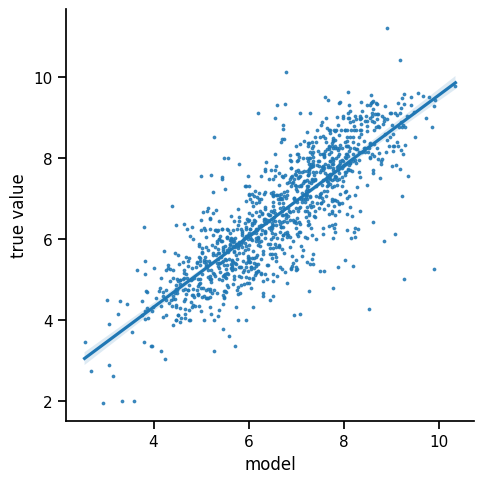

In [9]:
pred = single_model(x_test)
sns.lmplot(
    data=pd.DataFrame(
        {
            "model": pred.flatten().detach().numpy(),
            "true value": y_test.flatten().detach().numpy(),
        }
    ),
    x="model",
    y="true value",
    scatter_kws={"s": 3},
)

# 平均绝对误差
mae_single_model = torch.abs(pred - y_test).sum().item()

# 均方误差
mse_single_model = ((pred - y_test) ** 2).sum().item()

display(
    Markdown(
        f"The mean absolute error is {mae_single_model:.2f} and the mean squared error is {mse_single_model:.2f}."
    )
)

我们观察到预测的 pIC50 与测量值之间存在合理的相关性。
看起来我们的模型已经学会从指纹特征中提取一些结合亲和力信息。


### 集成——多次训练模型


In [10]:
ensemble_size = 20
ensemble = []
for _ in tqdm.tqdm(range(ensemble_size)):
    training_data = TensorDataset(x_train, y_train)
    training_loader = DataLoader(training_data, batch_size=32, shuffle=True)
    model = create_and_fit_model(
        training_loader,
    )
    ensemble.append(model)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [03:50<00:00, 11.53s/it]


In [11]:
preds = torch.stack([model(x_test) for model in ensemble]).reshape(ensemble_size, len(x_test))

我们现在在矩阵 `pred` 中拥有了所有集成和测试样本上的预测。我们可以计算每个测试数据点的基本统计量，如均值和方差。方差或标准差被用作预测的不确定性估计。


In [12]:
stds = preds.std(0)
var = preds.var(0)
mean = preds.mean(0)
mae = torch.abs(mean - y_test.flatten())
total_mae = mae.sum().item()
total_mse = torch.sum((mean - y_test.flatten()) ** 2).item()

现在，将集成均值作为预测器与上面的单一模型预测器进行比较是很有趣的。


The mean absolute error decreased from 758.59 to 727.53. The mean squared error decreased from 891.53 to 833.26.

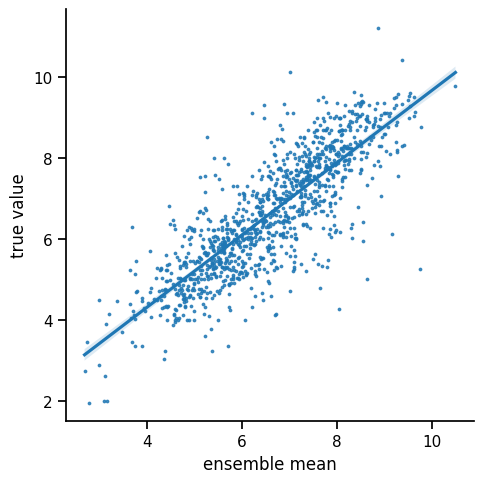

In [13]:
sns.lmplot(
    pd.DataFrame(
        {
            "ensemble mean": mean.detach().numpy(),
            "true value": y_test.flatten().detach().numpy(),
        }
    ),
    x="ensemble mean",
    y="true value",
    scatter_kws={"s": 3},
)

display(
    Markdown(
        f"The mean absolute error decreased from {mae_single_model:.2f} to {total_mae:.2f}. The mean squared error decreased from {mse_single_model:.2f} to {total_mse:.2f}."
    )
)

如我们所见，测试集上的预测质量提高了。
最初引入模型集成是为了提高预测质量的一种手段（参见 [Sagi and Rokach 2018](https://wires.onlinelibrary.wiley.com/doi/abs/10.1002/widm.1249)）。
直观上，这是通过减轻单一模型的异常值来实现的。


#### 置信区间的覆盖

对于每个置信水平，我们可以基于从模型集成中获得的标准差计算置信区间。
根据置信区间在水平 $p$ 的定义，该区间应以概率 $p$ 覆盖实际值。
因此，如果我们绘制 $[0,1]$ 中所有水平的命中率与测试集的关系，理想情况下我们会得到一条完美的对角线（恒等函数）。


In [14]:
confidences = np.linspace(0, 1)

hits = []
for c in confidences:
    delta = stds * norm.ppf(0.5 + c / 2) / np.sqrt(ensemble_size)
    a = np.array((mean - delta < y_test.flatten()) & (mean + delta > y_test.flatten())).astype(int)
    hits.append(a.sum() / len(a))

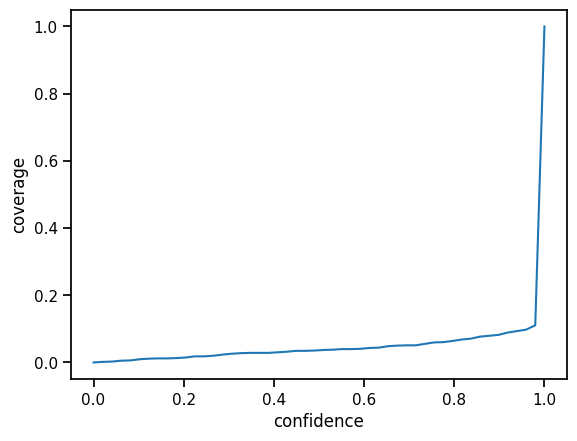

In [15]:
plt.plot(confidences, hits)
plt.ylabel("coverage")
plt.xlabel("confidence")
plt.yscale("linear")

#### 校准


首先，我们在测试集的一个小的、专用的部分上计算置信曲线。基于置信曲线，我们计算估计标准差的调整因子。这个过程可以通过计算更复杂的变换来优化。例如，我们可以为任意数量的_区间_（即间隔置信度）计算这样的因子。


In [16]:
num_calib = 100
preds_calibration = torch.stack([model(x_test[:num_calib]) for model in ensemble]).reshape(
    ensemble_size, num_calib
)

stds_calibration = preds_calibration.std(0)
mean_calibration = preds_calibration.mean(0)
confidences = np.linspace(0, 1)
hits_calibration = []
for c in confidences:
    delta = stds_calibration * norm.ppf(0.5 + c / 2) / np.sqrt(ensemble_size)
    a = np.array(
        (mean_calibration - delta < y_test[:num_calib].flatten())
        & (mean_calibration + delta > y_test[:num_calib].flatten())
    ).astype(int)
    hits_calibration.append(a.sum() / len(a))
calibration_adjustment = (confidences / hits_calibration)[1:-1]
calibration_adjustment = calibration_adjustment[calibration_adjustment != torch.inf].mean()

恒定的校准调整因子 `calibration_adjustment` 用于计算置信区间。
得到的置信曲线现在校准得好多了。
这意味着它接近恒等函数。


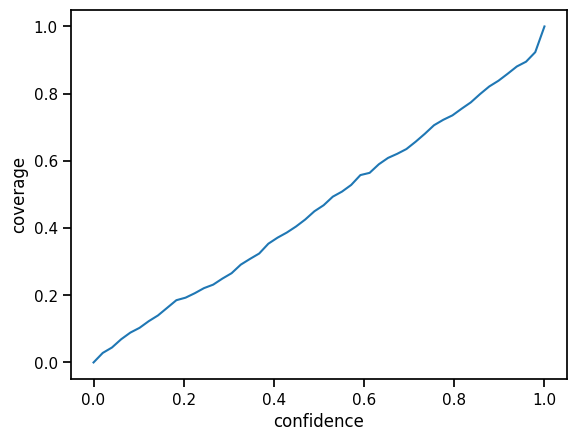

In [17]:
hits = []
for c in confidences:
    delta = (calibration_adjustment * stds * norm.ppf(0.5 + c / 2) / np.sqrt(len(ensemble)))[
        num_calib:
    ]
    a = np.array(
        (mean[num_calib:] - delta < y_test[num_calib:].flatten())
        & (mean[num_calib:] + delta > y_test[num_calib:].flatten())
    ).astype(int)
    hits.append(a.sum() / len(a))

plt.plot(confidences, hits)
plt.ylabel("coverage")
plt.xlabel("confidence")
plt.yscale("linear")

好多了！要获得更好的校准，我们可以使用更复杂的校准方法。例如，我们可以使用基于区间的方案。特别是当曲线在过度估计或低估置信度方面不一致时，这种灵活的方案更合适。


#### 基于排序的评估

到目前为止，我们还没有真正审视我们的集成在估计不确定性方面的有用性。理想情况下，较差的估计会表明我们的预测——至少潜在上——具有更高的误差。为了在这个意义上评估我们的不确定性预测，我们可以查看_置信曲线_。在这种基于排序的方案中，我们按照不确定性递减的顺序对估计值进行排序，并查看一定数量样本下总绝对误差的减少量。然后，我们可以将生成的曲线与随机基线和理想曲线进行比较。


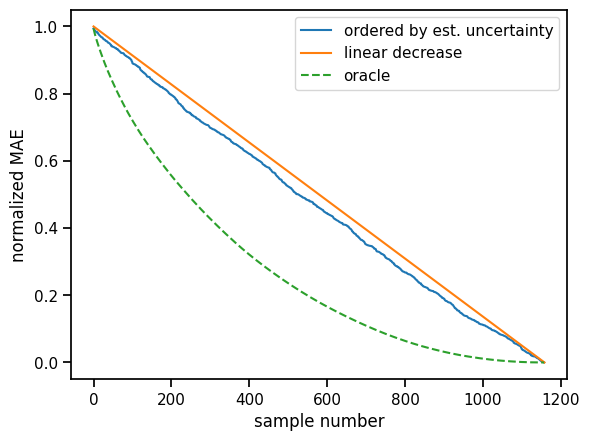

In [18]:
idcs_mae = torch.argsort(mae, 0, descending=True).flatten()
idcs_conf = torch.argsort(stds, 0, descending=True).flatten()
plt.plot(
    (total_mae - torch.cumsum(mae[idcs_conf].flatten(), 0)).detach().numpy() / total_mae,
    label="ordered by est. uncertainty",
)
plt.plot(
    [0, len(x_test)],
    [1, 0],
    label="linear decrease",
)
plt.plot(
    (total_mae - torch.cumsum(mae[idcs_mae], 0)).detach().numpy() / total_mae,
    "--",
    label="oracle",
)
plt.legend()
plt.xlabel("sample number")
plt.ylabel("normalized MAE");

理想情况下，蓝色曲线（即我们的不确定性估计）应该介于随机基线和理想曲线之间。我们看到与基线相比有一些改进，但仍有改进空间。通常，模型集成需要更多的多样性。
下面我们通过自助法和聚合训练数据来创建更多多样性。
另一种方法是在集成内以某种方式改变模型本身。


### 为集成引入更多方差


通常，仅通过改变模型暴露于训练样本的顺序，集成中的方差太小。
为了更好地捕获不确定性，我们需要在集成中引入更多多样性。有两个领域可以引入更多的集成方差：数据和模型。

#### 改变训练数据

除了改变训练运行之外，我们还额外改变训练数据。
这是通过对数据进行_bootstrapping and aggregating_（_bagging_）来完成的：
对于每次运行，我们使用替换对训练数据进行重新采样，以获得每个模型（可能）略微不同的训练集。此外，我们只使用该重新采样数据的一个子集，可能对某些集成成员隐藏一些数据点。

#### 改变模型参数

我们可以进一步改变整个集成中的模型参数。这种变化应该驱动模型以不同的方式学习底层数据。


In [19]:
ensemble_size = 20
ensemble_bagg = []
for _ in tqdm.tqdm(range(ensemble_size)):
    idcs = torch.randint(low=0, high=int(0.75 * len(x_train)), size=(len(x_train),))
    x_train_resample = x_train[idcs]
    y_train_resample = y_train[idcs]
    training_data = TensorDataset(x_train_resample, y_train_resample)
    training_loader = DataLoader(training_data, batch_size=32)

    model = create_and_fit_model(
        training_loader,
        model_args={
            "n_hidden": 2 ** np.random.randint(5, 10),
            "p_dropout": np.random.rand() * 0.1,
        },
    )
    ensemble_bagg.append(model)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [01:47<00:00,  5.38s/it]


现在，所有集成都已训练完成，我们计算所有集成成员的测试集预测。


In [20]:
preds_bagg = torch.stack([model(x_test) for model in ensemble_bagg]).reshape(
    ensemble_size, len(x_test)
)

同样，我们对集成预测计算基本统计量。


In [21]:
stds_bagg = preds_bagg.std(0)
var_bagg = preds_bagg.var(0)
mean_bagg = preds_bagg.mean(0)
mae_bagg = torch.abs(mean_bagg - y_test.flatten())
mse_bagg = (mean_bagg - y_test.flatten()) ** 2

#### 基于排序的评估

现在我们重复上面的基于排序的评估。即，我们将置信曲线与恒定的递减基线和最优解（Oracle）进行比较。


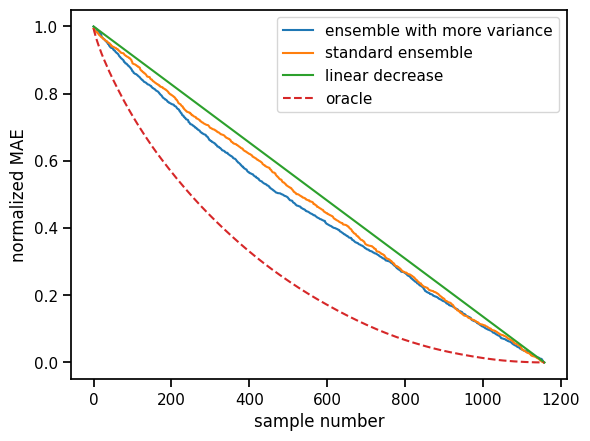

In [22]:
idcs_mae_bagg = torch.argsort(mae_bagg, 0, descending=True).flatten()
idcs_conf_bagg = torch.argsort(stds_bagg, 0, descending=True).flatten()
total_error = mae_bagg.sum().item()
plt.plot(
    (total_error - torch.cumsum(mae_bagg[idcs_conf_bagg].flatten(), 0)).detach().numpy()
    / total_error,
    label="ensemble with more variance",
)
plt.plot(
    (total_mae - torch.cumsum(mae[idcs_conf].flatten(), 0)).detach().numpy() / total_mae,
    label="standard ensemble",
)
plt.plot(
    [0, len(x_test)],
    [1, 0],
    label="linear decrease",
)
plt.plot(
    (total_error - torch.cumsum(mae_bagg[idcs_mae_bagg], 0)).detach().numpy() / total_error,
    "--",
    label="oracle",
)
plt.legend()
plt.xlabel("sample number")
plt.ylabel("normalized MAE");

我们观察到与基线一致的改进。这意味着不确定性估计帮助我们获得了估计质量的印象。
较差的估计更可能具有比好的估计更高的估计不确定性。


### 测试时数据增强


最后，我们展示测试时数据增强。其优点是它可以应用于几乎任何模型。
基本思想是对每个测试样本_附近_进行采样。
这组_相似_样本应该提供关于局部变异性的信息。
大的变异性被认为意味着更高的不确定性。

在指纹的背景下，我们处理的是固定长度的位串。
为了对每个测试样本附近进行采样，我们用 `N_AUG` 个额外样本来增强每个测试样本。
在每个样本和位置上，我们引入一个突变，即以固定概率（此处 $p=0.01$）翻转一个位。


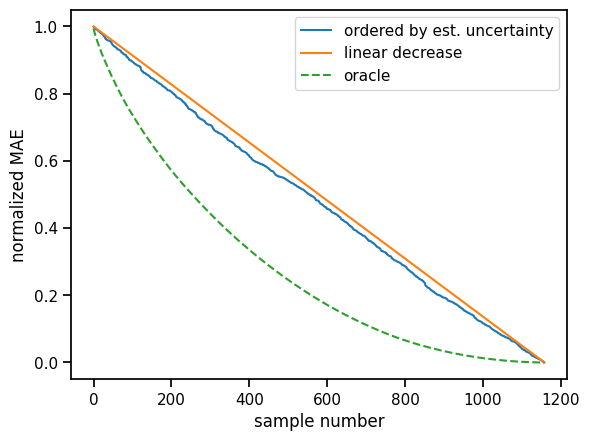

In [23]:
N_AUG = 200

x_test_aug = torch.repeat_interleave(x_test, N_AUG, dim=0)

mutations = torch.rand_like(x_test_aug) < 0.01
x_test_aug = torch.logical_xor(mutations, x_test_aug)

x_test_aug = torch.tensor(x_test_aug, dtype=torch.float32)

pred = single_model(x_test_aug)
pred = pred.reshape(-1, N_AUG, 1)
((pred.mean(1) - y_test) ** 2).sum()

stds_aug = pred.std(1)
mae_aug = torch.abs(pred.mean(1) - y_test)

torch.cumsum(mae_aug[torch.argsort(stds_aug, 0, descending=True).flatten()].flatten(), 0)

idcs_mae = torch.argsort(mae_aug, 0, descending=True).flatten()
idcs_conf = torch.argsort(stds_aug, 0, descending=True).flatten()
total_err = mae_aug.sum().item()
plt.plot(
    (total_err - torch.cumsum(mae_aug[idcs_conf].flatten(), 0)).detach().numpy() / total_err,
    label="ordered by est. uncertainty",
)
plt.plot(
    [0, len(x_test)],
    [1, 0],
    label="linear decrease",
)
plt.plot(
    (total_err - torch.cumsum(mae_aug[idcs_mae].flatten(), 0)).detach().numpy() / total_err,
    "--",
    label="oracle",
)
plt.legend()
plt.xlabel("sample number")
plt.ylabel("normalized MAE");

## 讨论

不确定性估计领域几乎与所有机器学习应用高度相关，计算机辅助药物发现也不例外。
因此，目前有大量精力投入到改进方法论上。
许多问题，如可解释性或不确定性量化的客观评估协议，仍有待解决。
然而，如果预测要应用于现实世界，就不能忽视不确定性。


## 测验

1. 不确定性的主要来源是什么？
2. 我们如何在不训练许多模型的情况下获得模型集成？
3. 在哪些场景中不确定性估计可能失败？
